# cu_inj Reference simulation

In [1]:
%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


In [2]:
from impact import Impact
from distgen import Generator
import os


GFILE = os.path.expandvars('$LCLS_LATTICE/distgen/models/cu_inj/v0/distgen.yaml')
YFILE = os.path.expandvars('$LCLS_LATTICE/impact/models/cu_inj/v0/ImpactT.yaml')

In [3]:
%%time
G = Generator(GFILE)
G['n_particle'] = 300_000
G.run()
P0 = G.particles

CPU times: user 3 s, sys: 166 ms, total: 3.16 s
Wall time: 3.17 s


# MPI run 300k particles

For this many particles we will prepare an MPI run

In [4]:
I = Impact.from_yaml(YFILE)

# Set initial particles
I.initial_particles = P0

## Switches for MPI
I.use_mpi=True
I.header['Nprow'] = 8
I.header['Npcol'] = 8
#I.stop = 1.4
I.mpi_run

'mpirun -n {n} {command_mpi}'

In [5]:
# Change some things
I.header['Nx'] = 64
I.header['Ny'] = 64
I.header['Nz'] = 64

# Run on Cori (NERSC)

In [6]:
%%time
I.command_mpi = '/global/homes/c/cmayes/cori/impact/bin/ImpactTv2.1_mpi'
I.workdir = os.path.expandvars('$SCRATCH')
I.mpi_run = 'salloc -N 1 -C haswell -q interactive -t 04:00:00 srun -n {n} {command_mpi} >log.txt' 
I.configure()

I.run()

CPU times: user 36.1 s, sys: 2.22 s, total: 38.4 s
Wall time: 11min 25s


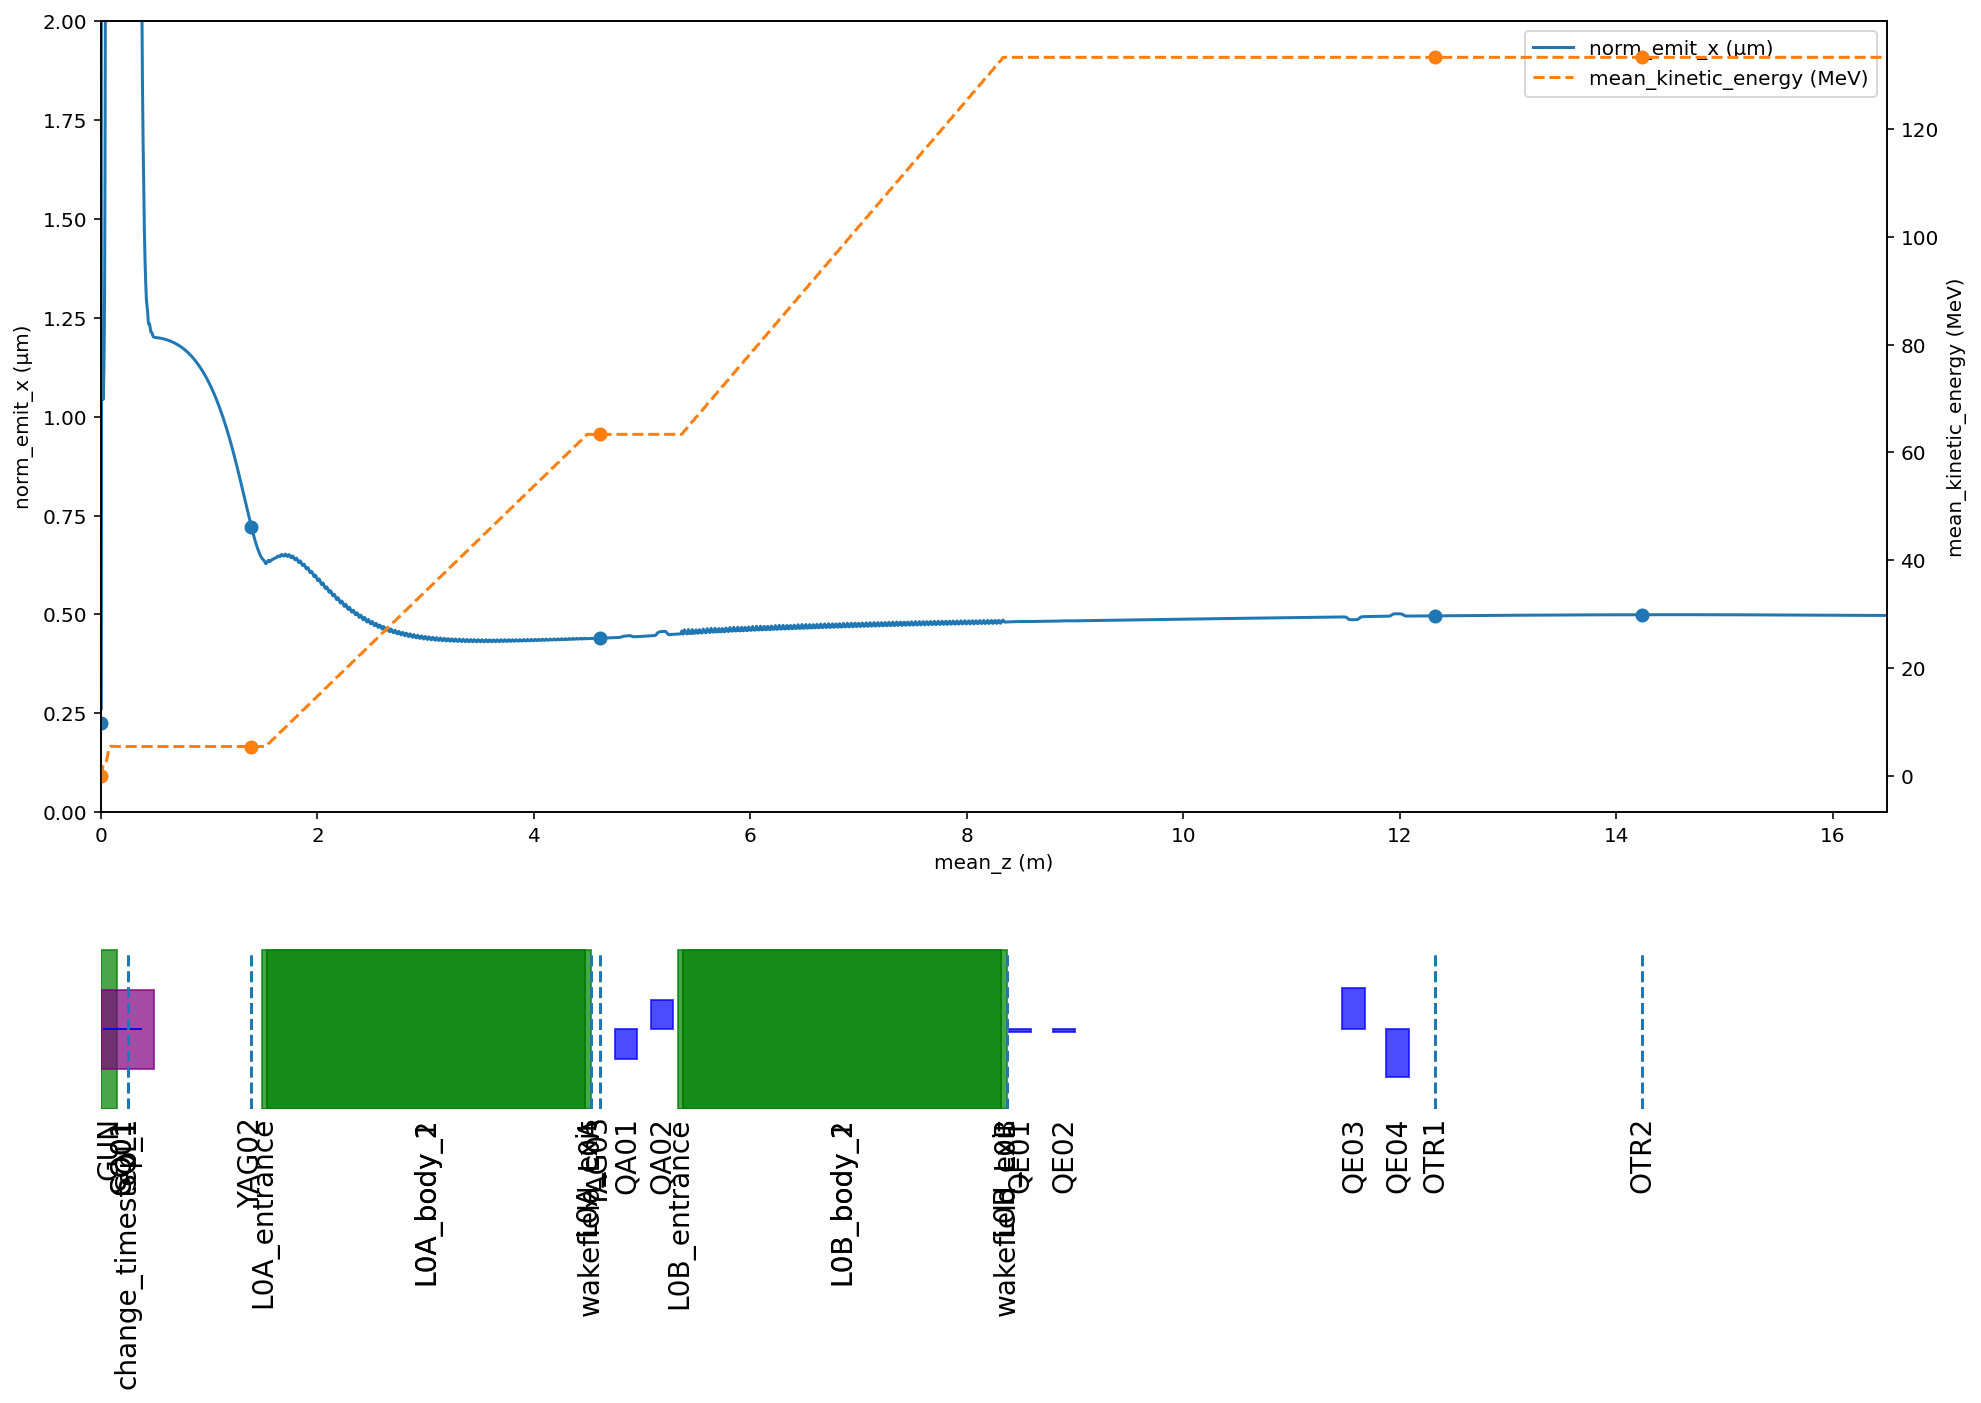

In [7]:
I.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(16,10), include_labels=True)

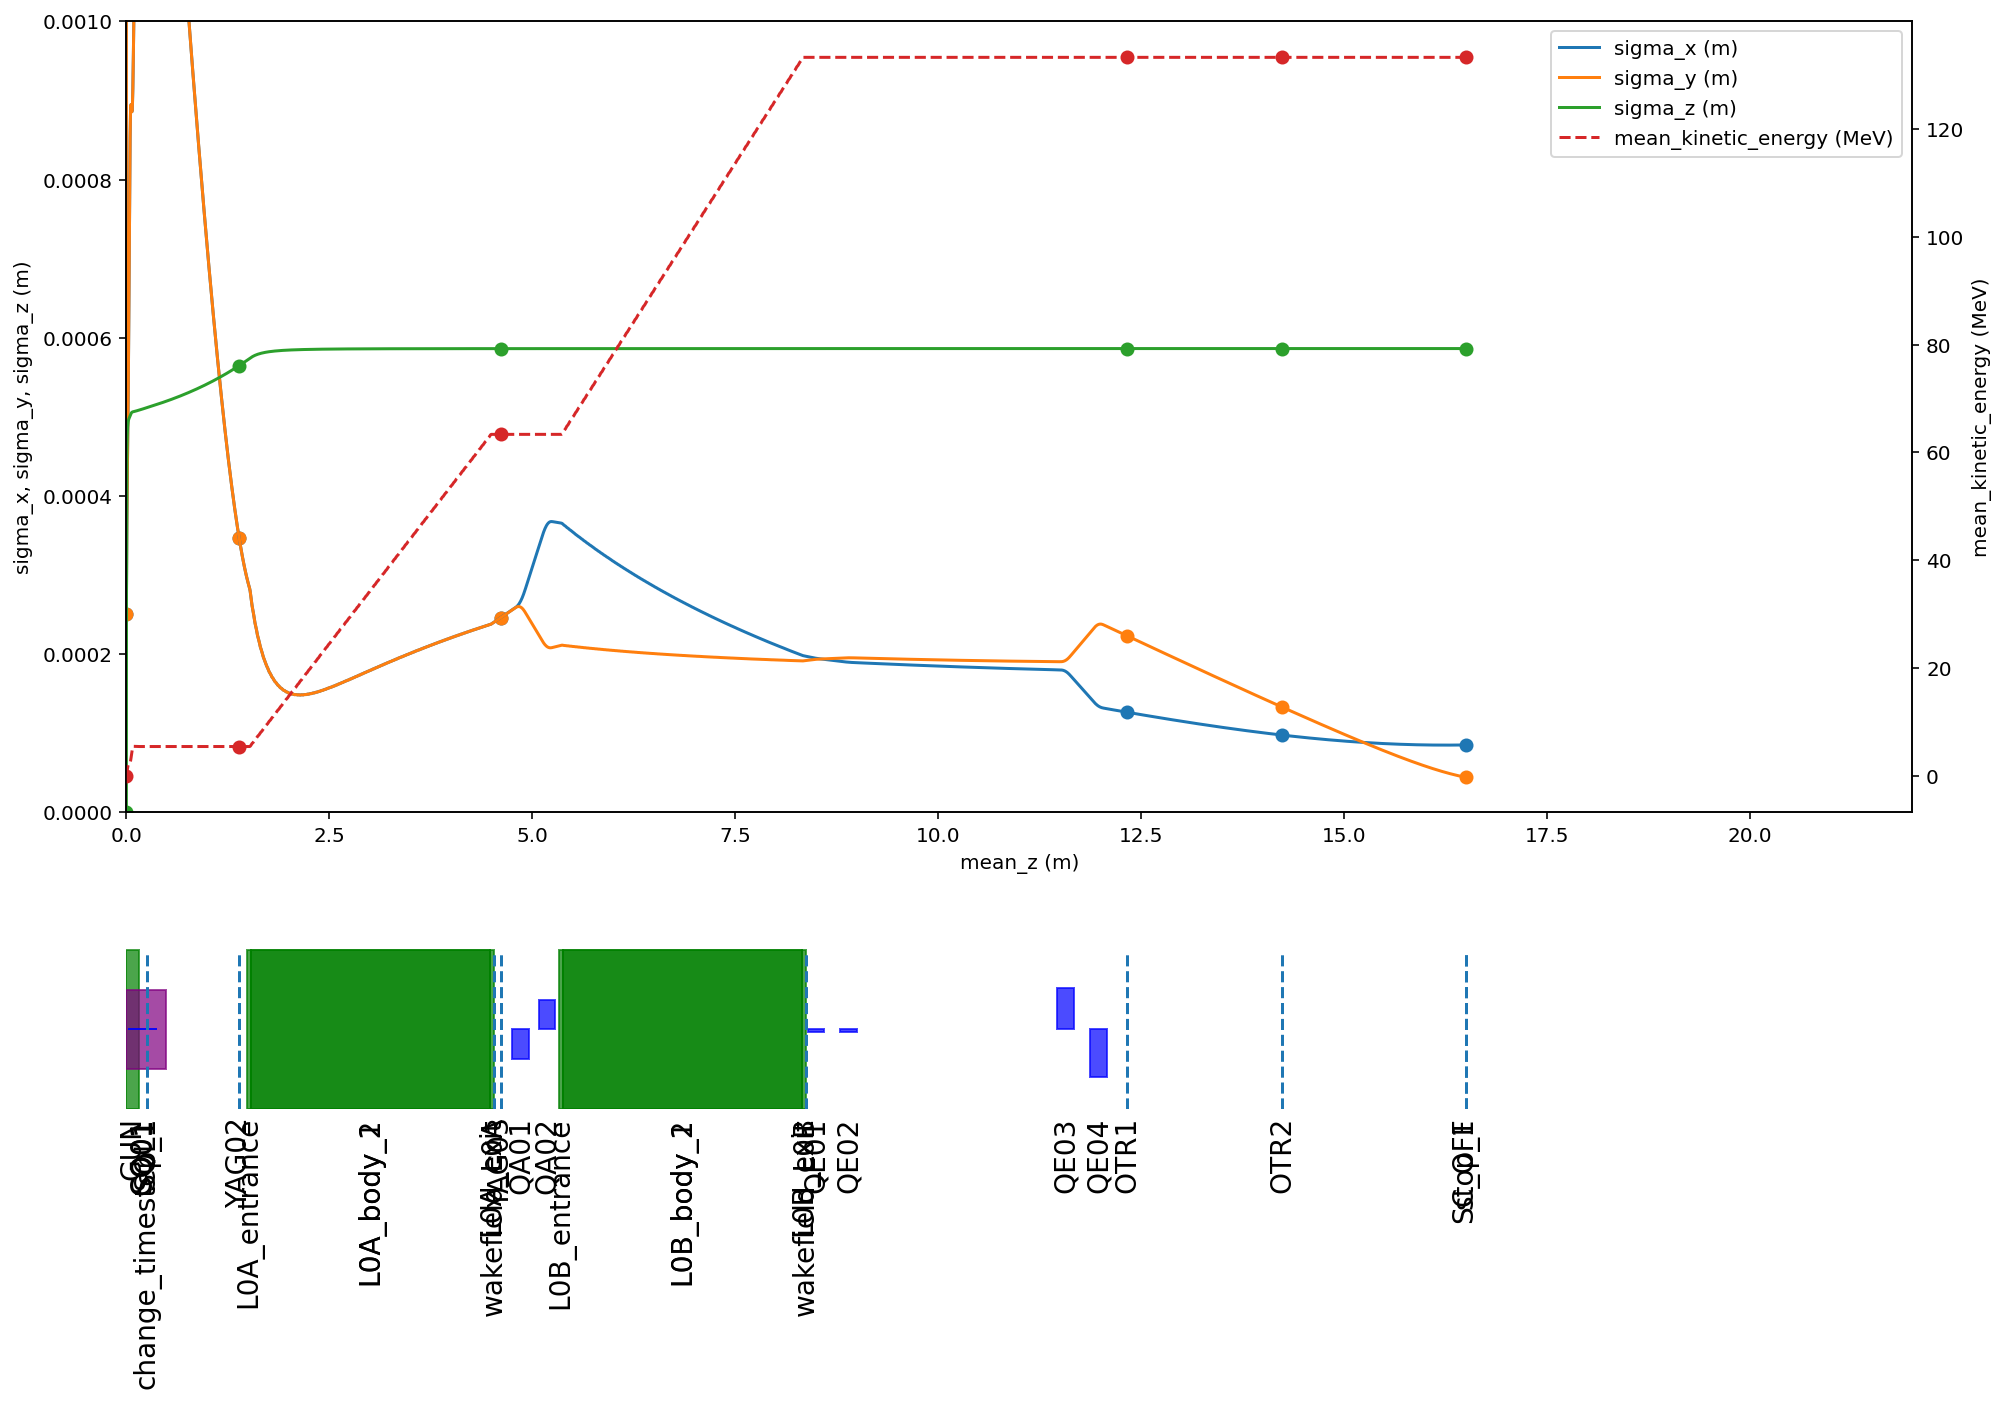

In [32]:
I.plot(['sigma_x', 'sigma_y', 'sigma_z'], y2='mean_kinetic_energy',  ylim=(0, 0.001), xlim=(0, 22), figsize=(16,10), include_labels=True)

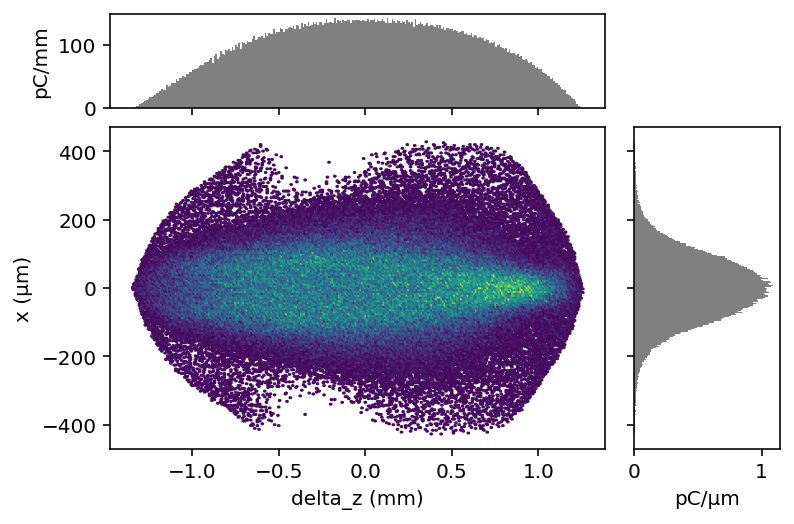

In [8]:
P1 = I.particles['OTR2']

P1.plot('delta_z', 'x')

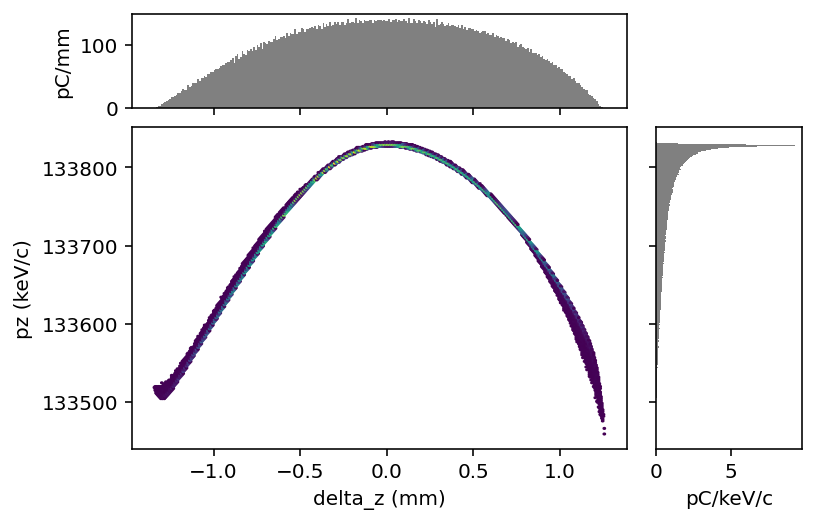

In [9]:
P1.plot('delta_z', 'pz')

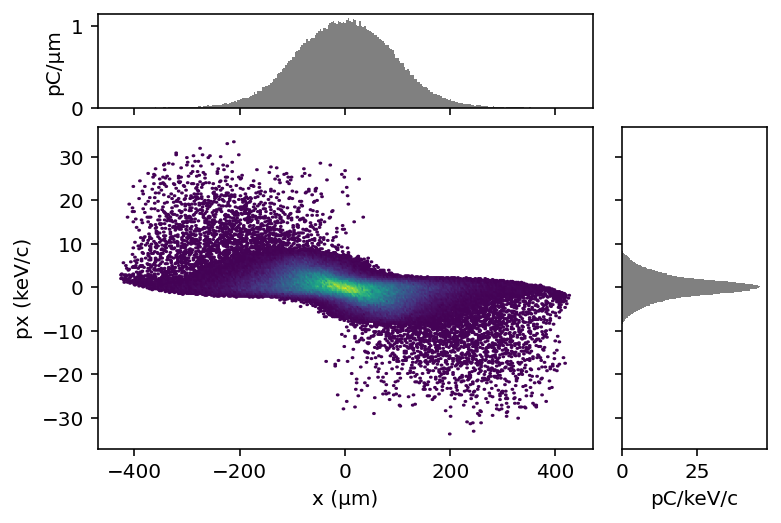

In [10]:
P1.plot('x', 'px')

In [11]:
# 95% Twiss and Emittance
P1.twiss('xy', 0.95)

{'alpha_x': 0.6247264621187036,
 'beta_x': 5.193762208342509,
 'gamma_x': 0.26768325092708367,
 'emit_x': 1.3633086888429998e-09,
 'eta_x': -1.1080757999739808e-05,
 'etap_x': 2.4365461242664367e-05,
 'norm_emit_x': 3.568556872200405e-07,
 'alpha_y': 3.3151904684628715,
 'beta_y': 9.65110498075724,
 'gamma_y': 1.2423953387818483,
 'emit_y': 1.3303222405356642e-09,
 'eta_y': 7.657052119274508e-05,
 'etap_y': -3.960318580194727e-05,
 'norm_emit_y': 3.482213283128717e-07}

In [13]:
# Copy basic input to `v0/`
#!cp {I.path}/ImpactT.in {os.path.split(YFILE)[0]}
#!cp {I.path}/partcl.data {os.path.split(YFILE)[0]}

In [14]:
#%%time
#afile = '/global/cfs/cdirs/m669/www/lume/cu_inj/impact_cu_inj_v0_300k_particles.h5'
#I.archive(afile)

CPU times: user 1min 36s, sys: 196 ms, total: 1min 36s
Wall time: 1min 44s


'/global/cfs/cdirs/m669/www/lume/cu_inj/impact_cu_inj_v0_300k_particles.h5'